RECURSIVE POLYNOMIAL BASIS ANALYSIS

1. Plotting recursive basis functions...
Figure saved to recursive_basis_experiments.png


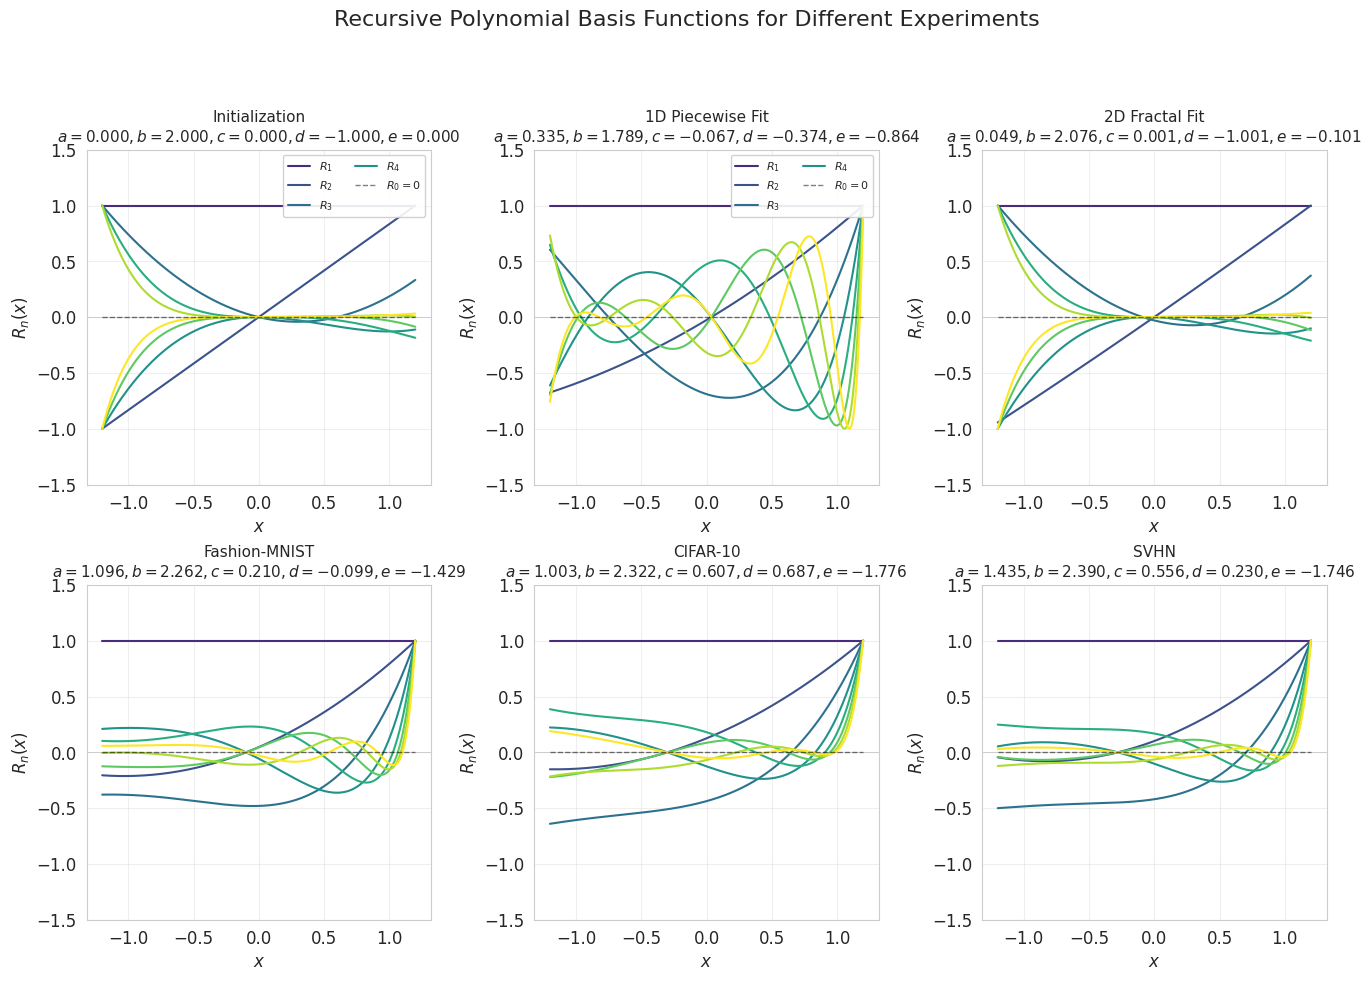


2. Plotting coefficient comparison...
Figure saved to coefficient_comparison.png


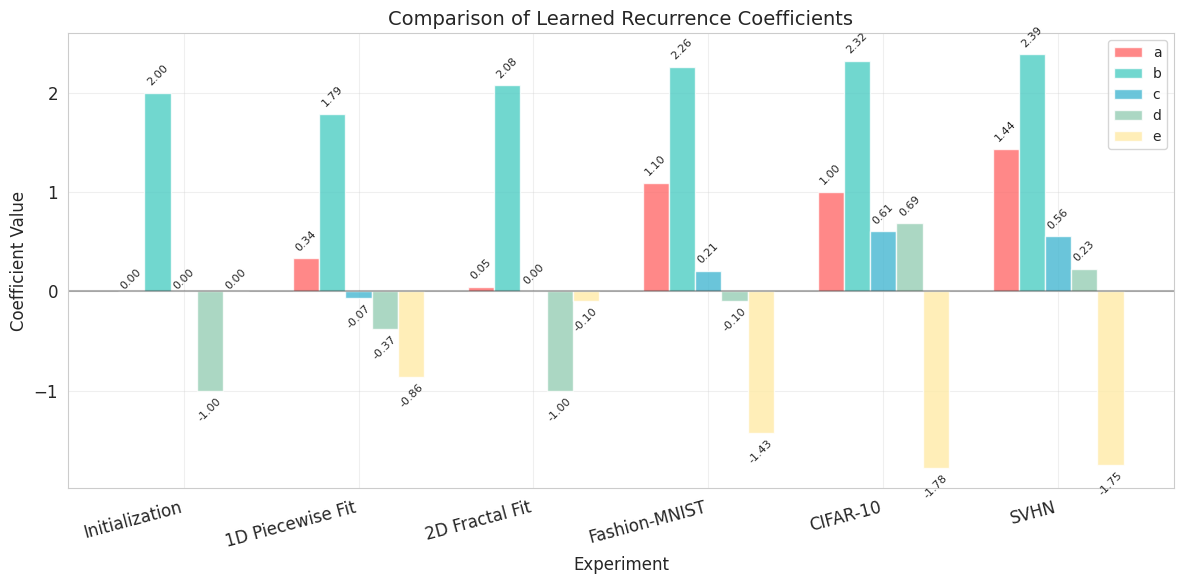


3. Plotting degree analysis...
Figure saved to degree_analysis.png


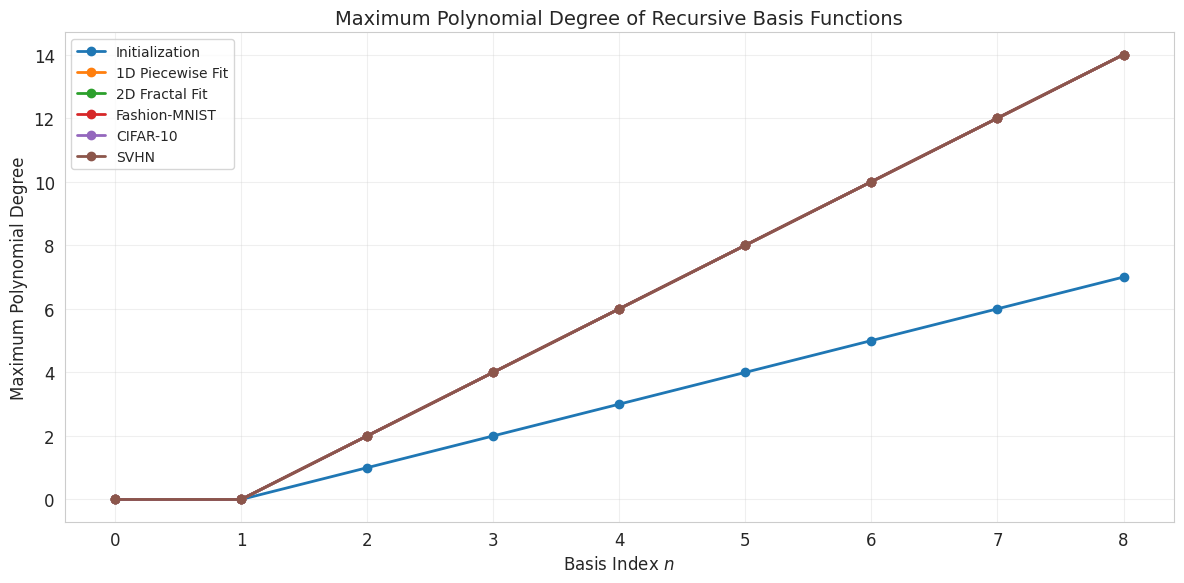


4. Plotting classical polynomial bases...
Figure saved to classical_vs_learned.png


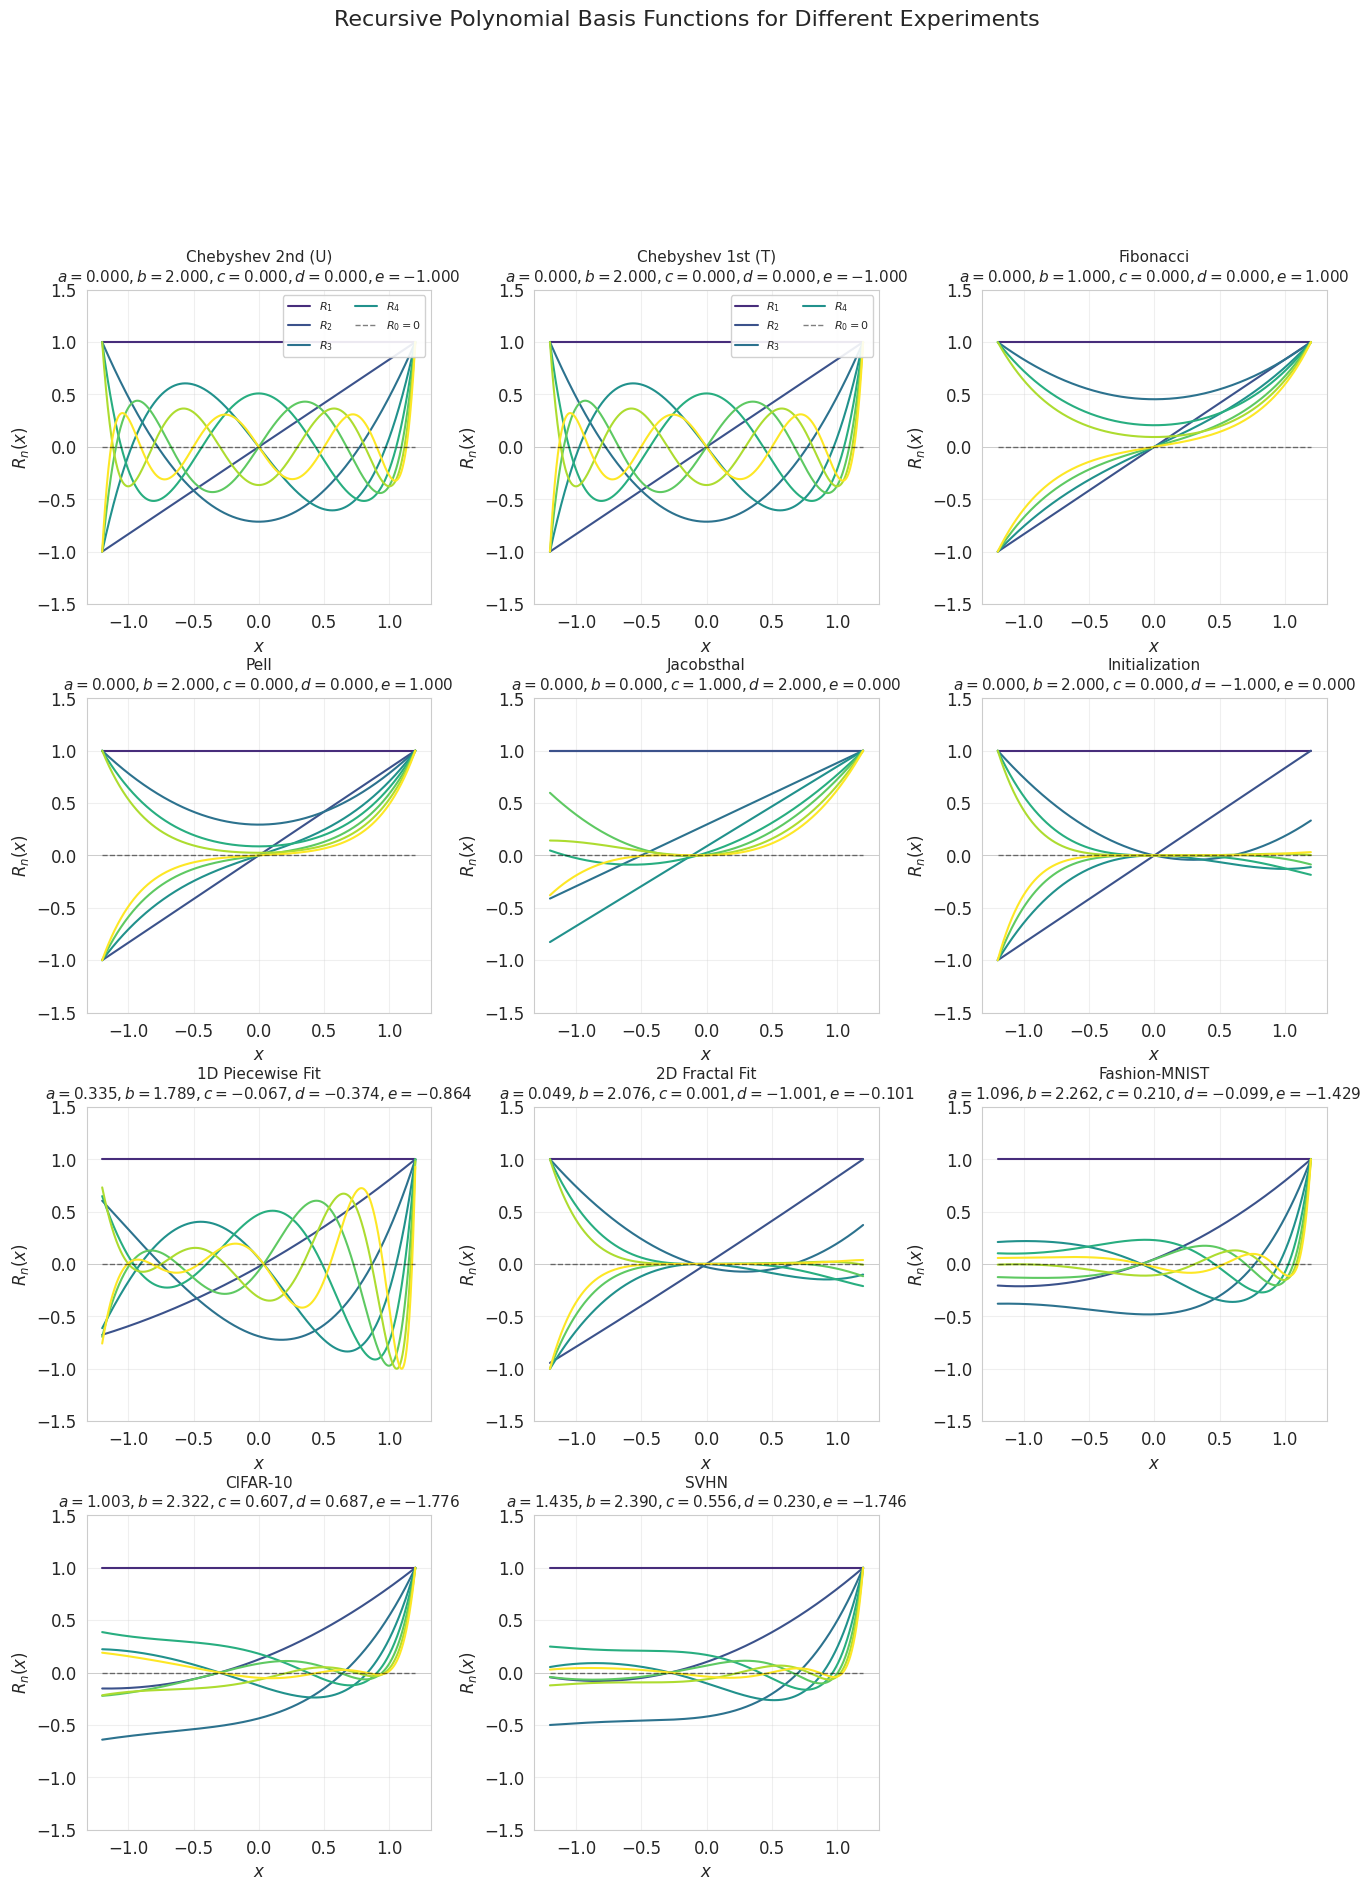


5. Detailed analysis of selected experiments...
Figure saved to selected_experiments.png


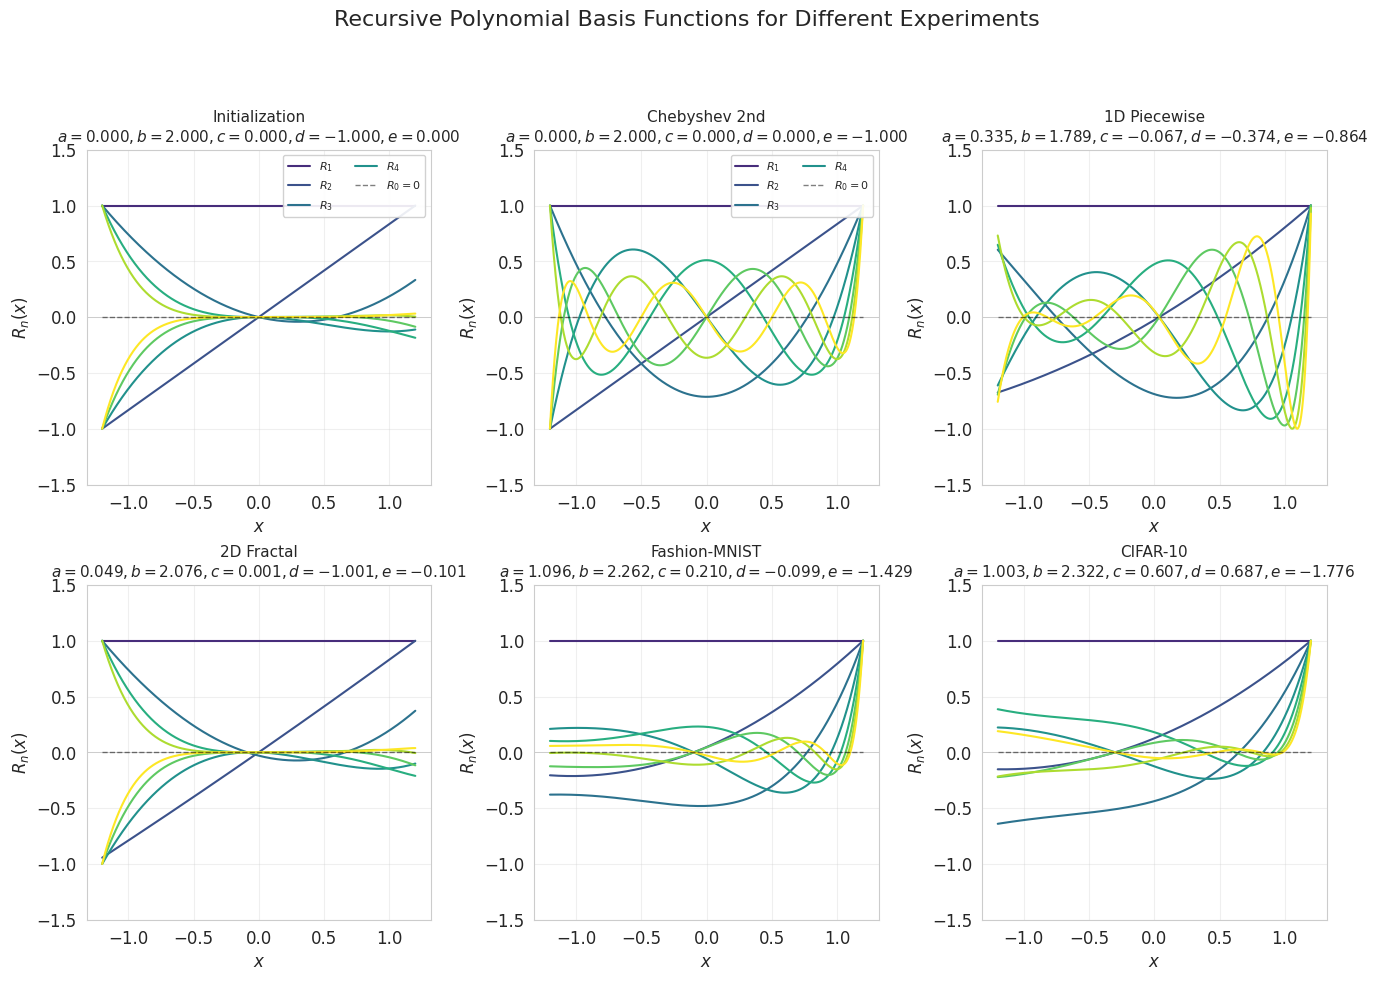


6. Coefficient table:
--------------------------------------------------------------------------------
Experiment                       a        b        c        d        e
--------------------------------------------------------------------------------
Initialization               0.000    2.000    0.000   -1.000    0.000
1D Piecewise Fit             0.335    1.789   -0.067   -0.374   -0.864
2D Fractal Fit               0.049    2.076    0.001   -1.001   -0.101
Fashion-MNIST                1.096    2.262    0.210   -0.099   -1.429
CIFAR-10                     1.003    2.322    0.607    0.687   -1.776
SVHN                         1.435    2.390    0.556    0.230   -1.746

7. Maximum polynomial degrees for each basis index:
----------------------------------------------------------------------
   Index n  Initializati  1D Piecewise  2D Fractal F  Fashion-MNIS      CIFAR-10
----------------------------------------------------------------------
         0             0             0    

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns
from scipy.special import eval_chebyt, eval_chebyu

sns.set_style("whitegrid")
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['legend.fontsize'] = 10

def recursive_polynomial(x, a, b, c, d, e, K):
 
    x = np.asarray(x)
    R = np.zeros((len(x), K+1))
    R[:, 0] = 0  # R0 = 0
    R[:, 1] = 1  # R1 = 1
    
    for n in range(1, K):
        alpha = a * x**2 + b * x + c
        beta = d * x + e
        R[:, n+1] = alpha * R[:, n] + beta * R[:, n-1]
        
        # نرمال‌سازی (مشابه الگوریتم مقاله)
        max_val = np.max(np.abs(R[:, n+1]))
        if max_val > 1e-10:
            R[:, n+1] = R[:, n+1] / max_val
    
    return R

def plot_recursive_basis(x, params_dict, K=10, save_path=None):
   
    n_experiments = len(params_dict)
    n_cols = min(3, n_experiments)
    n_rows = (n_experiments + n_cols - 1) // n_cols
    
    fig = plt.figure(figsize=(16, 5*n_rows))
    gs = GridSpec(n_rows, n_cols, figure=fig, hspace=0.3, wspace=0.3)
    
    colors = plt.cm.viridis(np.linspace(0, 1, K+1))
    
    for idx, (name, params) in enumerate(params_dict.items()):
        row = idx // n_cols
        col = idx % n_cols
        ax = fig.add_subplot(gs[row, col])
        
        a, b, c, d, e = params
        R = recursive_polynomial(x, a, b, c, d, e, K)
        
        for n in range(1, K+1):
            ax.plot(x, R[:, n], color=colors[n], linewidth=1.5, 
                   label=f'$R_{n}$' if n < 5 else None)
        
        ax.plot(x, R[:, 0], 'k--', linewidth=1, alpha=0.5, label='$R_0=0$')
        
        ax.set_title(f'{name}\n$a={a:.3f}, b={b:.3f}, c={c:.3f}, d={d:.3f}, e={e:.3f}$', 
                    fontsize=11)
        ax.set_xlabel('$x$')
        ax.set_ylabel('$R_n(x)$')
        ax.grid(True, alpha=0.3)
        ax.axhline(y=0, color='k', linestyle='-', alpha=0.2, linewidth=0.5)
        
        y_max = max(1.5, np.max(np.abs(R[:, 1:])) * 1.1)
        ax.set_ylim(-y_max, y_max)
        
        if idx < 2:
            ax.legend(loc='upper right', ncol=2, fontsize=8, framealpha=0.9)
    
    for idx in range(len(params_dict), n_rows * n_cols):
        row = idx // n_cols
        col = idx % n_cols
        if idx < n_rows * n_cols:
            fig.delaxes(fig.add_subplot(gs[row, col]))
    
    plt.suptitle('Recursive Polynomial Basis Functions for Different Experiments', 
                fontsize=16, y=1.02)
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure saved to {save_path}")
    
    plt.show()
    return fig

def plot_parameter_comparison(params_dict, save_path=None):
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    names = list(params_dict.keys())
    params = np.array(list(params_dict.values()))
    
    x = np.arange(len(names))
    width = 0.15
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']
    labels = ['a', 'b', 'c', 'd', 'e']
    
    for i, (label, color) in enumerate(zip(labels, colors)):
        offset = (i - 2) * width
        ax.bar(x + offset, params[:, i], width, label=label, color=color, alpha=0.8)
    
    ax.set_xlabel('Experiment')
    ax.set_ylabel('Coefficient Value')
    ax.set_title('Comparison of Learned Recurrence Coefficients')
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=15, ha='right')
    ax.legend(loc='upper right')
    ax.axhline(y=0, color='k', linestyle='-', alpha=0.3)
    ax.grid(True, alpha=0.3)
    
    for i, (label, color) in enumerate(zip(labels, colors)):
        offset = (i - 2) * width
        for j in range(len(names)):
            val = params[j, i]
            ax.text(j + offset, val + np.sign(val) * 0.05, 
                   f'{val:.2f}', ha='center', va='bottom' if val >= 0 else 'top',
                   fontsize=8, rotation=45)
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure saved to {save_path}")
    
    plt.tight_layout()
    plt.show()
    return fig

def plot_coefficient_evolution(history_dict, save_path=None):
    
    n_experiments = len(history_dict)
    fig, axes = plt.subplots(n_experiments, 1, figsize=(12, 4*n_experiments))
    
    if n_experiments == 1:
        axes = [axes]
    
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']
    labels = ['a', 'b', 'c', 'd', 'e']
    
    for idx, (name, history) in enumerate(history_dict.items()):
        ax = axes[idx]
        n_iter = len(history)
        iterations = np.arange(n_iter)
        
        for i, (label, color) in enumerate(zip(labels, colors)):
            ax.plot(iterations, history[:, i], label=label, color=color, linewidth=2)
        
        ax.set_title(f'{name}')
        ax.set_xlabel('Iteration')
        ax.set_ylabel('Coefficient Value')
        ax.legend(loc='upper right')
        ax.grid(True, alpha=0.3)
        ax.axhline(y=0, color='k', linestyle='-', alpha=0.2)
    
    plt.suptitle('Evolution of Recurrence Coefficients During Training', fontsize=14)
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure saved to {save_path}")
    
    plt.tight_layout()
    plt.show()
    return fig

def analyze_polynomial_degree(params, K=10):
   
    a = params[0]
    degrees = []
    for n in range(K+1):
        if n == 0:
            degrees.append(-np.inf)  # R0 = 0
        elif n == 1:
            degrees.append(0)  # R1 = 1
        else:
            if abs(a) > 1e-10:
                deg = 2 * (n - 1)
            else:
                deg = n - 1
            degrees.append(deg)
    return degrees

def plot_degree_analysis(params_dict, K=10, save_path=None):
   
    fig, ax = plt.subplots(figsize=(12, 6))
    
    n = np.arange(K+1)
    
    for name, params in params_dict.items():
        degrees = analyze_polynomial_degree(params, K)
        degrees_display = [0 if d == -np.inf else d for d in degrees]
        ax.plot(n, degrees_display, 'o-', linewidth=2, markersize=6, label=name)
    
    ax.set_xlabel('Basis Index $n$')
    ax.set_ylabel('Maximum Polynomial Degree')
    ax.set_title('Maximum Polynomial Degree of Recursive Basis Functions')
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)
    ax.set_xticks(n)
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure saved to {save_path}")
    
    plt.tight_layout()
    plt.show()
    return fig

experiments = {
    'Initialization': (0.000, 2.000, 0.000, -1.000, 0.000),
    '1D Piecewise Fit': (0.335, 1.789, -0.067, -0.374, -0.864),
    '2D Fractal Fit': (0.049, 2.076, 0.001, -1.001, -0.101),
    'Fashion-MNIST': (1.096, 2.262, 0.210, -0.099, -1.429),
    'CIFAR-10': (1.003, 2.322, 0.607, 0.687, -1.776),
    'SVHN': (1.435, 2.390, 0.556, 0.230, -1.746)
}

classical_bases = {
    'Chebyshev 2nd (U)': (0.000, 2.000, 0.000, 0.000, -1.000),
    'Chebyshev 1st (T)': (0.000, 2.000, 0.000, 0.000, -1.000), 
    'Fibonacci': (0.000, 1.000, 0.000, 0.000, 1.000),
    'Pell': (0.000, 2.000, 0.000, 0.000, 1.000),
    'Jacobsthal': (0.000, 0.000, 1.000, 2.000, 0.000)
}


if __name__ == "__main__":
    x = np.linspace(-1.2, 1.2, 1000)
    K = 8  
    
    print("=" * 70)
    print("RECURSIVE POLYNOMIAL BASIS ANALYSIS")
    print("=" * 70)
    
    print("\n1. Plotting recursive basis functions...")
    plot_recursive_basis(x, experiments, K=K, save_path='recursive_basis_experiments.png')
    
    print("\n2. Plotting coefficient comparison...")
    plot_parameter_comparison(experiments, save_path='coefficient_comparison.png')
    
    print("\n3. Plotting degree analysis...")
    plot_degree_analysis(experiments, K=K, save_path='degree_analysis.png')
    
    print("\n4. Plotting classical polynomial bases...")
    all_bases = {**classical_bases, **experiments}
    plot_recursive_basis(x, all_bases, K=K, save_path='classical_vs_learned.png')
    
    print("\n5. Detailed analysis of selected experiments...")
    selected = {
        'Initialization': experiments['Initialization'],
        'Chebyshev 2nd': classical_bases['Chebyshev 2nd (U)'],
        '1D Piecewise': experiments['1D Piecewise Fit'],
        '2D Fractal': experiments['2D Fractal Fit'],
        'Fashion-MNIST': experiments['Fashion-MNIST'],
        'CIFAR-10': experiments['CIFAR-10']
    }
    
    fig = plot_recursive_basis(x, selected, K=K, save_path='selected_experiments.png')
    
    # 6. نمایش جدول ضرایب
    print("\n6. Coefficient table:")
    print("-" * 80)
    print(f"{'Experiment':<25} {'a':>8} {'b':>8} {'c':>8} {'d':>8} {'e':>8}")
    print("-" * 80)
    for name, params in experiments.items():
        print(f"{name:<25} {params[0]:>8.3f} {params[1]:>8.3f} {params[2]:>8.3f} {params[3]:>8.3f} {params[4]:>8.3f}")
    
    # 7. محاسبه و نمایش درجه چندجمله‌ای‌ها
    print("\n7. Maximum polynomial degrees for each basis index:")
    print("-" * 70)
    print(f"{'Index n':>10}", end="")
    for name in list(experiments.keys())[:5]:
        print(f"{name[:12]:>14}", end="")
    print()
    print("-" * 70)
    
    for n in range(K+1):
        print(f"{n:>10}", end="")
        for name, params in list(experiments.items())[:5]:
            deg = analyze_polynomial_degree(params, K)[n]
            deg_display = 0 if deg == -np.inf else deg
            print(f"{deg_display:>14}", end="")
        print()
    
    # 8. ذخیره نتایج در فایل
    print("\n8. Saving results to file...")
    with open('recursive_basis_analysis.txt', 'w') as f:
        f.write("RECURSIVE POLYNOMIAL BASIS ANALYSIS\n")
        f.write("=" * 70 + "\n\n")
        f.write("Coefficients for each experiment:\n")
        f.write("-" * 80 + "\n")
        f.write(f"{'Experiment':<25} {'a':>8} {'b':>8} {'c':>8} {'d':>8} {'e':>8}\n")
        f.write("-" * 80 + "\n")
        for name, params in experiments.items():
            f.write(f"{name:<25} {params[0]:>8.3f} {params[1]:>8.3f} {params[2]:>8.3f} {params[3]:>8.3f} {params[4]:>8.3f}\n")
        
        f.write("\n\nMaximum polynomial degrees:\n")
        f.write("-" * 70 + "\n")
        f.write(f"{'Index n':>10}")
        for name in list(experiments.keys())[:5]:
            f.write(f"{name[:12]:>14}")
        f.write("\n" + "-" * 70 + "\n")
        for n in range(K+1):
            f.write(f"{n:>10}")
            for name, params in list(experiments.items())[:5]:
                deg = analyze_polynomial_degree(params, K)[n]
                deg_display = 0 if deg == -np.inf else deg
                f.write(f"{deg_display:>14}")
            f.write("\n")
    
    print("\nAnalysis complete! All figures and results have been saved.")
    print("Files created:")
    print("  - recursive_basis_experiments.png")
    print("  - coefficient_comparison.png")
    print("  - degree_analysis.png")
    print("  - classical_vs_learned.png")
    print("  - selected_experiments.png")
    print("  - recursive_basis_analysis.txt")